In [ ]:
pip install sunpy pyspedas

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [ ]:
import pyspedas
from pyspedas import time_string
from pyspedas import tplot, get_data

import sunpy
import sunpy.coordinates as scoordss
import sys, os
import datetime
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

In [ ]:
#beautify plots

import matplotlib as mpl

mpl.rcParams['mathtext.default' ]='regular'
mpl.rcParams['font.size'        ]=12
mpl.rcParams['figure.figsize'   ]=(6,4)
mpl.rcParams['figure.dpi'       ]=180
mpl.rcParams['axes.linewidth'   ]=1.2
mpl.rcParams['xtick.major.size' ]=5
mpl.rcParams['xtick.minor.size' ]=4
mpl.rcParams['ytick.major.size' ]=5
mpl.rcParams['ytick.minor.size' ]=3
mpl.rcParams['xtick.major.width']=1
mpl.rcParams['ytick.major.width']=1
mpl.rcParams['xtick.direction'  ]='out'
mpl.rcParams['ytick.direction'  ]='out'

mpl.rcParams['savefig.bbox'     ]='tight'

mpl.rcParams['animation.html'   ]='jshtml'

In [ ]:
### Set range of timestamps
dt_start = "2020-11-10 00:00:00"
dt_end = "2020-11-16 00:00:00"

mfi = pyspedas.projects.omni.data(trange=[dt_start,dt_end],datatype='1min',time_clip=True);
B_GSE = get_data('BX_GSE')

date_obj = [datetime.datetime.strptime(time_string(d), '%Y-%m-%d %H:%M:%S.%f') for d in B_GSE.times]

rd = {'Time': date_obj, 'Bx': get_data('BX_GSE').y, 'By': get_data('BY_GSE').y, 'Bz':get_data('BZ_GSE').y,
     'Vx':  get_data('Vx').y,
      'Vy':   get_data('Vy').y,
      'Vz':   get_data('Vz').y,
      'np':   get_data('proton_density').y,
      'Tp':  get_data('T').y,
    'P' : get_data('Pressure').y,
     'sym-h': get_data('SYM_H').y}
sw = pd.DataFrame(data=rd)

sw.head()

08-Jun-26 16:05:19: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2020/
08-Jun-26 16:05:20: Downloading https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2020/omni_hro_1min_20201101_v01.cdf to omni_data/hro_1min/2020/omni_hro_1min_20201101_v01.cdf
08-Jun-26 16:05:20: Download of omni_data/hro_1min/2020/omni_hro_1min_20201101_v01.cdf complete, 8.359 MB in 0.2 sec (44.245 MB/sec) (transfer_normal)
08-Jun-26 16:05:26: /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



,Time,Bx,By,Bz,Vx,Vy,Vz,np,Tp,P,sym-h
0,2020-11-10 00:00:00,2.55,-4.45,1.21,-343.600006,-15.8,1.6,3.52,27959.0,0.83,0
1,2020-11-10 00:01:00,2.60,-4.43,1.14,-342.500000,-15.0,1.3,3.41,26525.0,0.80,0
2,2020-11-10 00:02:00,2.54,-4.42,1.27,-342.600006,-15.2,1.6,3.52,27936.0,0.83,0
3,2020-11-10 00:03:00,2.60,-4.43,1.26,-341.299988,-14.4,1.6,3.53,28766.0,0.82,0
4,2020-11-10 00:04:00,2.48,-4.52,1.14,-340.799988,-14.1,1.5,3.54,29049.0,0.82,0


08-Jun-26 16:05:26: /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



08-Jun-26 16:05:27: /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



The mean V of the high-speed stream is: 362.5 km/s


08-Jun-26 16:05:29: /usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)

08-Jun-26 16:05:29: /usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()

08-Jun-26 16:05:29: /usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")

08-Jun-26 16:05:29: /usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(

08-Jun-26 16:05:29: /usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()


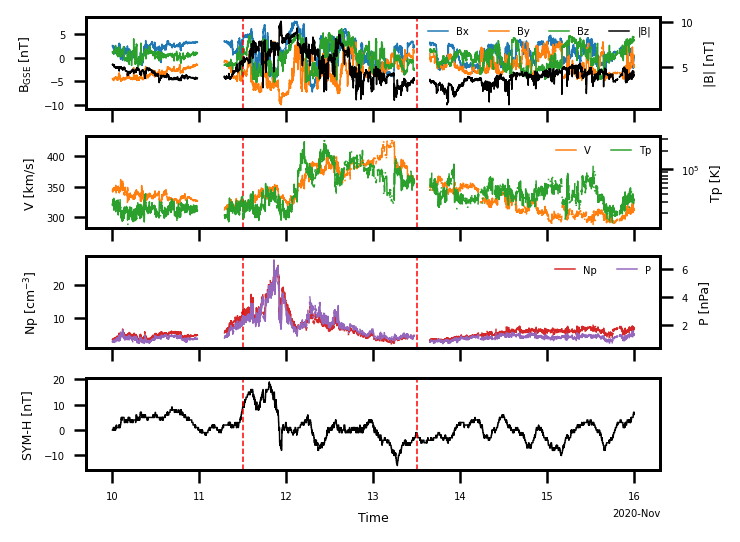

In [ ]:
# Prepare data
df = sw.copy()
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

df['B'] = np.sqrt(df['Bx']**2 + df['By']**2 + df['Bz']**2)
df['V'] = np.sqrt(df['Vx']**2 + df['Vy']**2 + df['Vz']**2)

# Set smaller fonts and thinner lines for compact figure
mpl.rcParams.update({
    "font.size": 5,
    "axes.titlesize": 5,
    "axes.labelsize": 5,
    "xtick.labelsize": 4,
    "ytick.labelsize": 4,
    "legend.fontsize": 4,
    "lines.linewidth": 0.6,
})

# Create a compact figure with 4 subplots
fig, axs = plt.subplots(4, 1, figsize=(4, 2.9), sharex=True, constrained_layout=True)

# 1. Magnetic field components + total B
ax0a = axs[0]
ax0b = ax0a.twinx()
ax0a.plot(df.index, df['Bx'], label='Bx')
ax0a.plot(df.index, df['By'], label='By')
ax0a.plot(df.index, df['Bz'], label='Bz')
ax0a.set_ylabel(r'B$_{GSE}$ [nT]')
ax0b.plot(df.index, df['B'], color='black', label='|B|')
ax0b.set_ylabel('|B| [nT]')
lines_a, labels_a = ax0a.get_legend_handles_labels()
lines_b, labels_b = ax0b.get_legend_handles_labels()
axs[0].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right', frameon=False, ncol=4)

# 2. Velocity + Temperature
ax1a = axs[1]
ax1b = ax1a.twinx()
ax1a.plot(df.index, df['V'], color='tab:orange', label='V')
ax1a.set_ylabel('V [km/s]')
ax1b.plot(df.index, df['Tp'], color='tab:green', label='Tp')
ax1b.set_ylabel('Tp [K]')
ax1b.set_yscale('log')
lines_a, labels_a = ax1a.get_legend_handles_labels()
lines_b, labels_b = ax1b.get_legend_handles_labels()
axs[1].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right', frameon=False, ncol=2)

# 3. Density + Pressure
ax2a = axs[2]
ax2b = ax2a.twinx()
ax2a.plot(df.index, df['np'], color='tab:red', label='Np')
ax2a.set_ylabel(r'Np [cm$^{-3}$]')
ax2b.plot(df.index, df['P'], color='tab:purple', label='P')
ax2b.set_ylabel('P [nPa]')
lines_a, labels_a = ax2a.get_legend_handles_labels()
lines_b, labels_b = ax2b.get_legend_handles_labels()
axs[2].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right', frameon=False, ncol=2)

# 4. SYM-H
axs[3].plot(df.index, df['sym-h'], color='black')
axs[3].set_ylabel('SYM-H [nT]')
axs[3].set_xlabel('Time')

# Add vertical lines for HSS interval - updated to be within the 2020 data range
t0 = pd.Timestamp("2020-11-11 12:00:00")
t1 = pd.Timestamp("2020-11-13 12:00:00")
for ax in axs:
    ax.axvline(t0, color="red", linestyle="--", linewidth=0.6)
    ax.axvline(t1, color="red", linestyle="--", linewidth=0.6)

# Print average velocity
df_v = df[t0:t1]
print("The mean V of the high-speed stream is: {:.1f} km/s".format(df_v["V"].mean()))

# Save the reduced-size figure
plt.savefig('Insitu_Final_small.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Find the peak velocity and its time
peak_velocity_time = df['V'].idxmax()
peak_velocity_value = df['V'].max()

print(f"Peak velocity: {peak_velocity_value:.2f} km/s")
print(f"Time of peak velocity: {peak_velocity_time}")

08-Jun-26 16:05:42: /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Peak velocity: 425.75 km/s
Time of peak velocity: 2020-11-13 05:03:00


In [ ]:
one_au_km = 149597870.7  # 1 AU in kilometers

# Calculate travel time in seconds
travel_time_seconds_peak = one_au_km / peak_velocity_value

# Convert travel time to a timedelta object
travel_time_timedelta_peak = pd.to_timedelta(travel_time_seconds_peak, unit='s')

# Calculate departure time
t_departure_peak = peak_velocity_time - travel_time_timedelta_peak

print(f"Arrival time at 1 AU (peak velocity time): {peak_velocity_time}")
print(f"Estimated travel time from Sun to 1 AU: {travel_time_timedelta_peak}")
print(f"Estimated departure time from solar surface (based on peak velocity): {t_departure_peak}")

Arrival time at 1 AU (peak velocity time): 2020-11-13 05:03:00
Estimated travel time from Sun to 1 AU: 4 days 01:36:15.621721019
Estimated departure time from solar surface (based on peak velocity): 2020-11-09 03:26:44.378278981


In [ ]:
import pandas as pd
url='https://helioforecast.space/static/sync/icmecat/HELIO4CAST_ICMECAT_v23.csv'
ic=pd.read_csv(url)

ic = ic[ic["sc_insitu"]=="Wind"]

ic["icme_start_time"] = pd.to_datetime(ic["icme_start_time"], utc=True).dt.tz_localize(None)

ic["mo_end_time"] = pd.to_datetime(ic["mo_end_time"], utc=True).dt.tz_localize(None)

#I am choosing 2018 as a reference

df_cme = ic[ic["icme_start_time"].dt.year==2020].iloc[:, [3,5]]

df_cme

08-Jun-26 16:05:43: /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



,icme_start_time,mo_end_time
655,2020-11-01 11:54:00,2020-11-03 07:06:00
660,2020-10-05 06:52:00,2020-10-06 11:58:00
670,2020-07-24 01:42:00,2020-07-25 11:36:00
673,2020-07-13 20:18:00,2020-07-14 06:18:00
675,2020-06-30 01:12:00,2020-07-01 16:10:00
677,2020-06-26 18:04:00,2020-06-27 00:48:00
682,2020-05-29 21:20:00,2020-05-30 15:54:00
687,2020-04-20 01:34:00,2020-04-21 11:18:00
690,2020-02-17 22:36:00,2020-02-18 21:10:00
693,2020-01-04 09:06:00,2020-01-05 05:10:00


08-Jun-26 16:05:43: /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

